# Portable Laptop QC Notebook

Cleaned notebook for loading the exported bundle, inspecting nucleus masks, reconstructing serpentine time, plotting core QC figures, and testing improved best-Z selection.

## 1. User settings

In [1]:

from pathlib import Path

# --- local paths ---
BUNDLE_DIR = Path(r"C:/Users/cowboy/OneDrive/Documents/University of Alabama/Nuclear_Scaling/Data_Sets/Control/portable_laptop_bundle")
RAW_IMAGE_PATH = None  # keep None unless you specifically want to load a local raw image

# --- acquisition assumptions ---
PIXEL_SIZE_UM = 0.162
N_FOV = 6
SERPENTINE = True

# --- default napari view ---
NAPARI_T_IDX = 0
NAPARI_SHOW_ALL_Z = True
AUTO_OPEN_NAPARI = False


## 2. Imports and helper functions

In [2]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def load_table_prefer_parquet_csv_pickle(stem: Path):
    parquet_path = stem.with_suffix(".parquet")
    csv_path = stem.with_suffix(".csv")
    pkl_path = stem.with_suffix(".pkl")

    if parquet_path.exists():
        return pd.read_parquet(parquet_path), parquet_path
    if csv_path.exists():
        return pd.read_csv(csv_path), csv_path
    if pkl_path.exists():
        return pd.read_pickle(pkl_path), pkl_path

    return None, None


def safe_read_tiff(path: Path, memmap_preferred: bool = True):
    if path is None:
        return None
    path = Path(path)
    if not path.exists():
        return None
    if memmap_preferred:
        try:
            return tiff.memmap(path)
        except Exception:
            pass
    return tiff.imread(path)


def describe_df(df: pd.DataFrame, name: str, n: int = 5):
    if df is None:
        print(f"{name}: missing")
        return
    print(f"{name}: shape={df.shape}")
    print(f"Columns: {list(df.columns)}")
    display(df.head(n))


def ensure_area_um2(df: pd.DataFrame, pixel_size_um: float, area_px_col: str = "area_px", area_um2_col: str = "nucleus_area_um2"):
    if df is None or df.empty:
        return df
    out = df.copy()
    if area_um2_col not in out.columns:
        if area_px_col not in out.columns:
            raise ValueError(f"Missing both '{area_um2_col}' and '{area_px_col}'")
        out[area_um2_col] = out[area_px_col] * (pixel_size_um ** 2)
    return out


def reconstruct_true_time_from_x(df: pd.DataFrame, n_fov: int = 6, serpentine: bool = True):
    if df is None or df.empty:
        return df
    required = ["t", "centroid_x_px"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for time reconstruction: {missing}")

    out = df.copy()
    max_x = out["centroid_x_px"].max()
    if pd.isna(max_x) or max_x <= 0:
        raise ValueError("Could not infer FOV width from centroid_x_px")

    fov_width = max_x / n_fov
    out["fov_id"] = (out["centroid_x_px"] // fov_width).astype(int)
    out["fov_id"] = out["fov_id"].clip(0, n_fov - 1)

    if serpentine:
        reverse_mask = out["t"] % 2 == 1
        out.loc[reverse_mask, "fov_id"] = (n_fov - 1) - out.loc[reverse_mask, "fov_id"]

    out["true_time_min"] = out["t"] * n_fov + out["fov_id"]
    return out


def add_fill_fraction(df: pd.DataFrame):
    if df is None or df.empty:
        return df
    needed = ["bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col", "area_px"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for fill_fraction: {missing}")

    out = df.copy()
    bbox_height = (out["bbox_max_row"] - out["bbox_min_row"]).clip(lower=1)
    bbox_width = (out["bbox_max_col"] - out["bbox_min_col"]).clip(lower=1)
    out["bbox_area_px"] = bbox_height * bbox_width
    out["fill_fraction"] = out["area_px"] / out["bbox_area_px"]
    return out


## 3. Load bundle tables and masks

In [3]:

bundle_dir = BUNDLE_DIR
assert bundle_dir.exists(), f"Bundle directory not found: {bundle_dir}"

manifest_path = bundle_dir / "manifest.json"
config_path = bundle_dir / "config" / "pipeline_config.json"
tables_dir = bundle_dir / "tables"
masks_dir = bundle_dir / "masks"

manifest = load_json(manifest_path) if manifest_path.exists() else {}
config = load_json(config_path) if config_path.exists() else {}

print("Bundle:", bundle_dir.resolve())
print("Manifest found:", manifest_path.exists())
print("Config found:", config_path.exists())


Bundle: C:\Users\cowboy\OneDrive\Documents\University of Alabama\Nuclear_Scaling\Data_Sets\Control\portable_laptop_bundle
Manifest found: True
Config found: True


In [4]:

table_names = [
    "segmentation_index",
    "segmentation_index_portable",
    "plane_objects",
    "grouped_z_objects",
    "best_z_nuclei",
    "best_z_nuclei_cleaned",
    "best_z_nuclei_with_exclusion",
    "best_z_nuclei_timed",
    "tracked_nuclei",
    "halo_analysis",
]

tables = {}
table_sources = {}

for name in table_names:
    df, src = load_table_prefer_parquet_csv_pickle(tables_dir / name)
    tables[name] = df
    table_sources[name] = src

mask_files = {
    "segmentation_class": masks_dir / "segmentation_class_hyperstack.tif",
    "segmentation_label": masks_dir / "segmentation_label_hyperstack.tif",
    "nucleus_instance": masks_dir / "nucleus_instance_hyperstack.tif",
    "droplet_instance": masks_dir / "droplet_instance_hyperstack.tif",
    "segmentation_prob": masks_dir / "segmentation_prob_hyperstack.tif",
}

mask_arrays = {
    name: safe_read_tiff(path) if path.exists() else None
    for name, path in mask_files.items()
}

raw_img = safe_read_tiff(Path(RAW_IMAGE_PATH)) if RAW_IMAGE_PATH is not None else None


## 4. Choose active tables and standardize core columns

In [5]:

seg_index_df = tables.get("segmentation_index_portable") or tables.get("segmentation_index")
plane_objects_df = tables.get("plane_objects")
grouped_z_df = tables.get("grouped_z_objects")

best_z_source_name = None
for candidate in ["best_z_nuclei_cleaned", "best_z_nuclei_timed", "best_z_nuclei_with_exclusion", "best_z_nuclei"]:
    if tables.get(candidate) is not None:
        best_z_df = tables[candidate].copy()
        best_z_source_name = candidate
        break
else:
    best_z_df = None

tracked_df = tables.get("tracked_nuclei")
halo_df = tables.get("halo_analysis")

if best_z_df is not None:
    best_z_df = ensure_area_um2(best_z_df, PIXEL_SIZE_UM)
    if {"t", "centroid_x_px"}.issubset(best_z_df.columns):
        best_z_df = reconstruct_true_time_from_x(best_z_df, n_fov=N_FOV, serpentine=SERPENTINE)

print("Active best_z source:", best_z_source_name)


Active best_z source: best_z_nuclei_timed


## 5. Quick summary

In [6]:

for name in table_names:
    src = table_sources.get(name)
    df = tables.get(name)
    print(f"{name:28s} ->", "missing" if df is None else f"{df.shape}  ({src.name if src else 'loaded'})")

print("\nMask shapes:")
for name, arr in mask_arrays.items():
    shape = None if arr is None else arr.shape
    print(f"{name:20s} -> {shape}")


segmentation_index           -> (200, 3)  (segmentation_index.csv)
segmentation_index_portable  -> missing
plane_objects                -> (27137, 10)  (plane_objects.csv)
grouped_z_objects            -> (27137, 11)  (grouped_z_objects.csv)
best_z_nuclei                -> (19443, 11)  (best_z_nuclei.csv)
best_z_nuclei_cleaned        -> missing
best_z_nuclei_with_exclusion -> (19443, 12)  (best_z_nuclei_with_exclusion.csv)
best_z_nuclei_timed          -> (19443, 17)  (best_z_nuclei_timed.csv)
tracked_nuclei               -> (19443, 25)  (tracked_nuclei.csv)
halo_analysis                -> (19443, 62)  (halo_analysis.csv)

Mask shapes:
segmentation_class   -> (10, 20, 3, 3889, 5732)
segmentation_label   -> (10, 20, 3889, 5732)
nucleus_instance     -> (10, 20, 3889, 5732)
droplet_instance     -> (10, 20, 3889, 5732)
segmentation_prob    -> None


## 6. Inspect the main working table

In [7]:

describe_df(best_z_df, f"best_z_df ({best_z_source_name})")


best_z_df (best_z_nuclei_timed): shape=(19443, 19)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'valid_single_nucleus', 'tile_row', 'tile_col', 'tile_index', 'tile_offset_min', 'true_time_min', 'nucleus_area_um2', 'fov_id']


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id,valid_single_nucleus,tile_row,tile_col,tile_index,tile_offset_min,true_time_min,nucleus_area_um2,fov_id
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,1,False,0,1,1,1.0,2,452.315340,2
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,2,False,0,0,0,0.0,1,400.614660,1
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,3,False,0,2,2,2.0,5,447.119028,5
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,4,True,0,2,2,2.0,4,222.942780,4
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,5,False,0,1,1,1.0,3,331.645428,3


## 7. Core plot helpers

In [8]:

def choose_time_column(df: pd.DataFrame):
    if df is None:
        return None, None
    if "true_time_min" in df.columns:
        return "true_time_min", "Time (min)"
    if "t" in df.columns:
        return "t", "Time index"
    return None, None


def plot_counts_by_time(df: pd.DataFrame, title: str = "Object count by time"):
    if df is None or df.empty:
        print("No data to plot.")
        return

    xcol, xlabel = choose_time_column(df)
    if xcol is None:
        print("No time column found.")
        return

    plot_df = df.groupby(xcol).size().reset_index(name="count")
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df[xcol], plot_df["count"], marker="o")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_area_distribution(df: pd.DataFrame, area_col: str = "nucleus_area_um2", title: str = "Area distribution"):
    if df is None or df.empty:
        print("No data to plot.")
        return

    plot_df = df.copy()
    if area_col not in plot_df.columns:
        plot_df = ensure_area_um2(plot_df, PIXEL_SIZE_UM)
        area_col = "nucleus_area_um2"

    vals = pd.to_numeric(plot_df[area_col], errors="coerce").dropna()
    plt.figure(figsize=(8, 4))
    plt.hist(vals, bins=50)
    plt.xlabel(area_col)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_max_cross_sectional_area_scatter(
    df: pd.DataFrame,
    pixel_size_um: float,
    n_fov: int = 6,
    serpentine: bool = True,
    title: str = "Max cross-sectional area vs time",
):
    if df is None or df.empty:
        print("No data to plot.")
        return None

    out = ensure_area_um2(df, pixel_size_um)
    out = reconstruct_true_time_from_x(out, n_fov=n_fov, serpentine=serpentine)

    plt.figure(figsize=(9, 4.5))
    plt.scatter(out["true_time_min"], out["nucleus_area_um2"], s=20, alpha=0.6)
    plt.xlabel("Time (min)")
    plt.ylabel("Max cross-sectional area (µm²)")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return out


## 8. Core QC plots

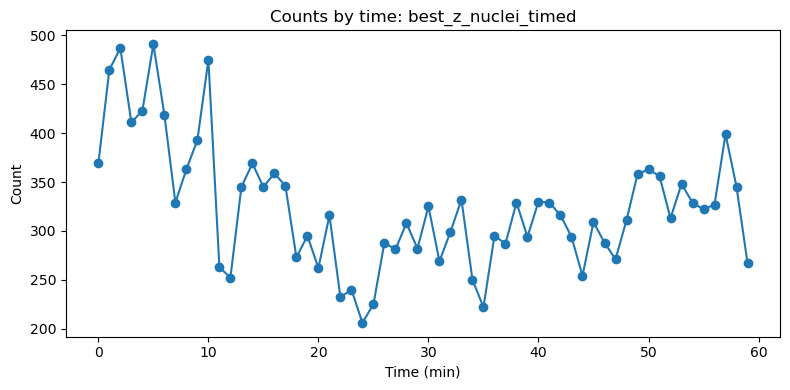

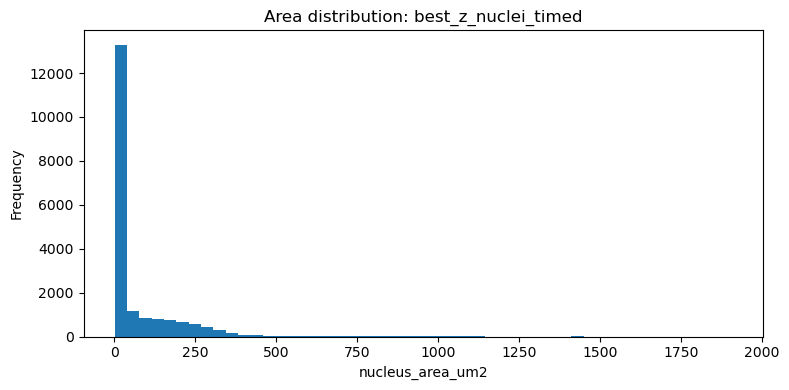

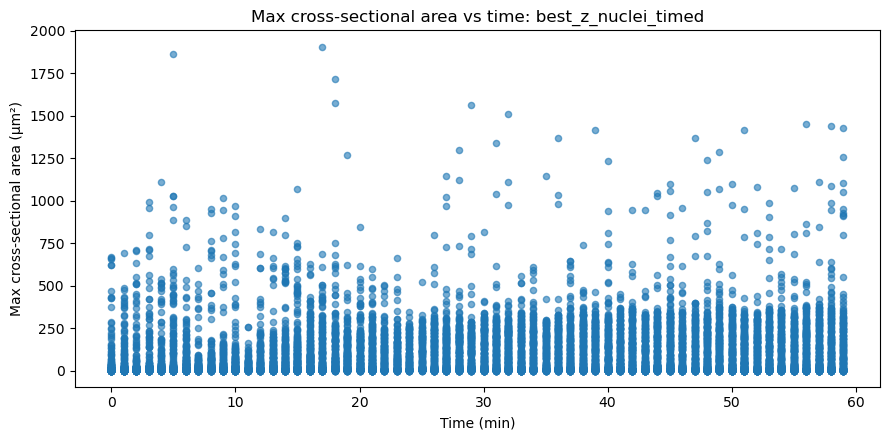

In [9]:

plot_counts_by_time(best_z_df, f"Counts by time: {best_z_source_name}")
plot_area_distribution(best_z_df, title=f"Area distribution: {best_z_source_name}")
best_z_plot_df = plot_max_cross_sectional_area_scatter(
    best_z_df,
    pixel_size_um=PIXEL_SIZE_UM,
    n_fov=N_FOV,
    serpentine=SERPENTINE,
    title=f"Max cross-sectional area vs time: {best_z_source_name}",
)


## 9. Best-Z selection test helpers

In [11]:

def select_best_z_by_composite_score(
    df: pd.DataFrame,
    group_col: str = "nucleus_3d_id",
    z_col: str = "z",
    area_col: str = "area_px",
    circularity_col: str = "circularity",
    fill_fraction_col: str = "fill_fraction",
    edge_col: str = "is_edge_touching",
    min_area_px: float = 20,
    area_weight: float = 0.45,
    circularity_weight: float = 0.25,
    fill_fraction_weight: float = 0.30,
    edge_penalty: float = 1.0,
) -> pd.DataFrame:
    if df is None or df.empty:
        return df.copy()

    required = [group_col, z_col, area_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    work = df.copy()

    if circularity_col not in work.columns:
        work[circularity_col] = 0.0
    if fill_fraction_col not in work.columns:
        work[fill_fraction_col] = 0.0
    if edge_col not in work.columns:
        work[edge_col] = False

    work = work[work[area_col] >= min_area_px].copy()
    if work.empty:
        return work

    def _normalize(series: pd.Series) -> pd.Series:
        smin = series.min()
        smax = series.max()
        if pd.isna(smin) or pd.isna(smax) or smax == smin:
            return pd.Series(np.zeros(len(series)), index=series.index)
        return (series - smin) / (smax - smin)

    selected_rows = []

    for _, g in work.groupby(group_col, dropna=False):
        g = g.copy()
        g["area_norm"] = _normalize(g[area_col].astype(float))
        g["circ_norm"] = _normalize(g[circularity_col].astype(float))
        g["fill_norm"] = _normalize(g[fill_fraction_col].astype(float))
        g["edge_penalty_val"] = g[edge_col].astype(float) * edge_penalty
        g["z_score"] = (
            area_weight * g["area_norm"]
            + circularity_weight * g["circ_norm"]
            + fill_fraction_weight * g["fill_norm"]
            - g["edge_penalty_val"]
        )
        g = g.sort_values(by=["z_score", area_col], ascending=[False, False])
        selected_rows.append(g.iloc[0])

    return pd.DataFrame(selected_rows).reset_index(drop=True)


def compare_best_z_tables(old_df: pd.DataFrame, new_df: pd.DataFrame, group_col: str = "nucleus_3d_id"):
    if old_df is None or new_df is None or old_df.empty or new_df.empty:
        print("Comparison unavailable.")
        return None

    needed = [group_col, "z", "area_px"]
    if not all(c in old_df.columns for c in needed) or not all(c in new_df.columns for c in needed):
        print("Missing required comparison columns.")
        return None

    cmp = (
        old_df[[group_col, "z", "area_px"]]
        .rename(columns={"z": "old_z", "area_px": "old_area_px"})
        .merge(
            new_df[[group_col, "z", "area_px"]].rename(columns={"z": "new_z", "area_px": "new_area_px"}),
            on=group_col,
            how="inner",
        )
    )
    cmp["z_changed"] = cmp["old_z"] != cmp["new_z"]
    cmp["area_changed"] = cmp["old_area_px"] != cmp["new_area_px"]
    return cmp


## 10. Run composite-score Z selection test

In [12]:

best_z_new_df = None
best_z_compare_df = None

if grouped_z_df is None or grouped_z_df.empty:
    print("grouped_z_df not available.")
else:
    grouped_z_work = grouped_z_df.copy()

    if {"bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col", "area_px"}.issubset(grouped_z_work.columns):
        grouped_z_work = add_fill_fraction(grouped_z_work)

    best_z_new_df = select_best_z_by_composite_score(grouped_z_work)
    best_z_new_df = ensure_area_um2(best_z_new_df, PIXEL_SIZE_UM)
    best_z_new_df = reconstruct_true_time_from_x(best_z_new_df, n_fov=N_FOV, serpentine=SERPENTINE)

    best_z_compare_df = compare_best_z_tables(best_z_df, best_z_new_df)
    describe_df(best_z_new_df, "best_z_new_df")
    if best_z_compare_df is not None:
        print("Rows compared:", len(best_z_compare_df))
        print("Z changed:", int(best_z_compare_df["z_changed"].sum()))
        print("Area changed:", int(best_z_compare_df["area_changed"].sum()))


best_z_new_df: shape=(19443, 23)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'bbox_area_px', 'fill_fraction', 'circularity', 'is_edge_touching', 'area_norm', 'circ_norm', 'fill_norm', 'edge_penalty_val', 'z_score', 'nucleus_area_um2', 'fov_id', 'true_time_min']


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,circularity,is_edge_touching,area_norm,circ_norm,fill_norm,edge_penalty_val,z_score,nucleus_area_um2,fov_id,true_time_min
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,...,0.0,False,0.0,0.0,0.0,0.0,0.00,452.315340,2,2
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,...,0.0,False,1.0,0.0,0.0,0.0,0.45,400.614660,1,1
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,...,0.0,False,1.0,0.0,0.0,0.0,0.45,447.119028,5,5
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,...,0.0,False,0.0,0.0,0.0,0.0,0.00,222.942780,4,4
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,...,0.0,False,0.0,0.0,0.0,0.0,0.00,331.645428,3,3


Rows compared: 19443
Z changed: 452
Area changed: 448


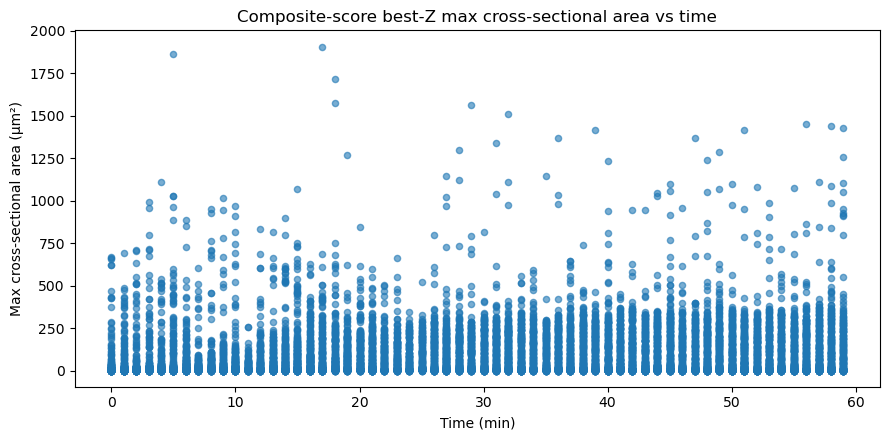

In [13]:

if best_z_new_df is not None and not best_z_new_df.empty:
    plot_max_cross_sectional_area_scatter(
        best_z_new_df,
        pixel_size_um=PIXEL_SIZE_UM,
        n_fov=N_FOV,
        serpentine=SERPENTINE,
        title="Composite-score best-Z max cross-sectional area vs time",
    )


## 11. Simple Z diagnostics

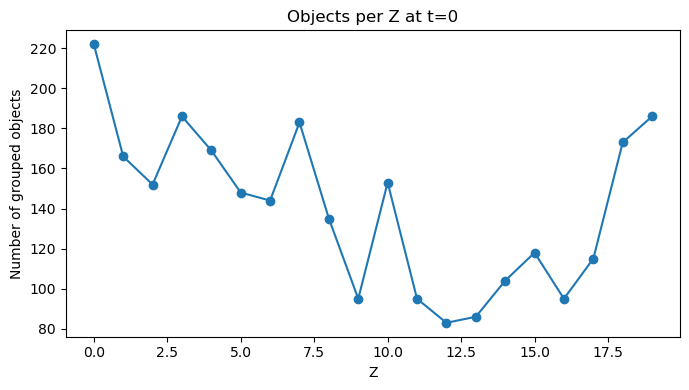

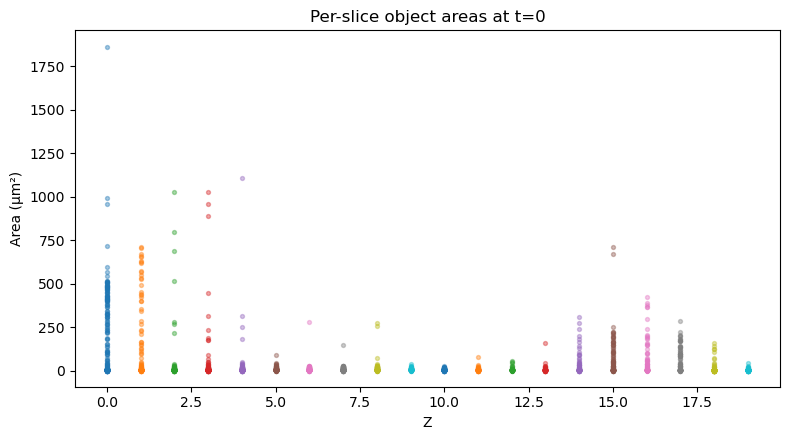

In [14]:

if grouped_z_df is not None and not grouped_z_df.empty:
    T_DIAG = int(grouped_z_df["t"].dropna().iloc[0])

    z_counts = grouped_z_df[grouped_z_df["t"] == T_DIAG].groupby("z").size()

    plt.figure(figsize=(7, 4))
    plt.plot(z_counts.index, z_counts.values, marker="o")
    plt.xlabel("Z")
    plt.ylabel("Number of grouped objects")
    plt.title(f"Objects per Z at t={T_DIAG}")
    plt.tight_layout()
    plt.show()

    plot_df = ensure_area_um2(grouped_z_df[grouped_z_df["t"] == T_DIAG], PIXEL_SIZE_UM)

    plt.figure(figsize=(8, 4.5))
    for z, g in plot_df.groupby("z"):
        plt.scatter([z] * len(g), g["nucleus_area_um2"], s=8, alpha=0.4)
    plt.xlabel("Z")
    plt.ylabel("Area (µm²)")
    plt.title(f"Per-slice object areas at t={T_DIAG}")
    plt.tight_layout()
    plt.show()


In [15]:
MIN_AREA_PX = 50  # tune this

df = df[df["area_px"] >= MIN_AREA_PX]

In [16]:
df = add_fill_fraction(df)

df = df[df["fill_fraction"] >= 0.5]

In [18]:
import pandas as pd


def add_fill_fraction(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    needed = ["bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col", "area_px"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for fill_fraction: {missing}")

    bbox_height = (df["bbox_max_row"] - df["bbox_min_row"]).clip(lower=1)
    bbox_width = (df["bbox_max_col"] - df["bbox_min_col"]).clip(lower=1)
    bbox_area = bbox_height * bbox_width

    df["bbox_area_px"] = bbox_area
    df["fill_fraction"] = df["area_px"] / bbox_area

    return df


def add_edge_touching_from_bbox(
    df: pd.DataFrame,
    edge_buffer_px: int = 5,
) -> pd.DataFrame:
    df = df.copy()

    bbox_cols = ["bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col"]
    missing = [c for c in bbox_cols if c not in df.columns]
    if missing:
        df["is_edge_touching"] = False
        return df

    # Infer image bounds from table extents
    image_height_px = df["bbox_max_row"].max()
    image_width_px = df["bbox_max_col"].max()

    df["is_edge_touching"] = (
        (df["bbox_min_row"] <= edge_buffer_px) |
        (df["bbox_min_col"] <= edge_buffer_px) |
        (df["bbox_max_row"] >= image_height_px - edge_buffer_px) |
        (df["bbox_max_col"] >= image_width_px - edge_buffer_px)
    )

    return df


def clean_grouped_objects_before_best_z(
    df: pd.DataFrame,
    min_area_px: float = 50,
    min_fill_fraction: float = 0.50,
    min_circularity: float | None = None,
    remove_edge_touching: bool = True,
    edge_buffer_px: int = 5,
) -> pd.DataFrame:
    if df is None or df.empty:
        print("No data to clean.")
        return df.copy()

    out = df.copy()

    # Area filter
    if "area_px" not in out.columns:
        raise ValueError("Missing required column 'area_px'")
    out = out[out["area_px"] >= min_area_px].copy()

    # Fill fraction
    out = add_fill_fraction(out)
    out = out[out["fill_fraction"] >= min_fill_fraction].copy()

    # Circularity if available
    if min_circularity is not None and "circularity" in out.columns:
        out = out[out["circularity"] >= min_circularity].copy()

    # Edge-touching
    if remove_edge_touching:
        if "is_edge_touching" not in out.columns:
            out = add_edge_touching_from_bbox(out, edge_buffer_px=edge_buffer_px)
        out = out[~out["is_edge_touching"]].copy()

    print("Rows after cleaning:", len(out))
    return out

In [19]:
grouped_z_clean_df = clean_grouped_objects_before_best_z(
    grouped_z_df,
    min_area_px=50,
    min_fill_fraction=0.50,
    min_circularity=None,   # set to 0.6 later if you add circularity upstream
    remove_edge_touching=True,
    edge_buffer_px=5,
)

Rows after cleaning: 22733


In [20]:
best_z_new_df = select_best_z_by_composite_score(
    grouped_z_clean_df,
    group_col="nucleus_3d_id",
    z_col="z",
    area_col="area_px",
    circularity_col="circularity",
    fill_fraction_col="fill_fraction",
    edge_col="is_edge_touching",
    min_area_px=20,
)

In [21]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_grouped_object_cleaning_diagnostics(
    raw_df: pd.DataFrame,
    cleaned_df: pd.DataFrame,
    t_value: int,
    pixel_size_um: float,
    area_px_col: str = "area_px",
    z_col: str = "z",
):
    """
    Plot before-vs-after grouped object diagnostics for one timepoint.

    Produces 4 plots:
      1. Objects per Z before cleaning
      2. Objects per Z after cleaning
      3. Per-slice area scatter before cleaning
      4. Per-slice area scatter after cleaning
    """

    if raw_df is None or raw_df.empty:
        print("raw_df is empty.")
        return
    if cleaned_df is None or cleaned_df.empty:
        print("cleaned_df is empty.")
        return

    if "t" not in raw_df.columns or "t" not in cleaned_df.columns:
        raise ValueError("Both dataframes must contain column 't'")
    if z_col not in raw_df.columns or z_col not in cleaned_df.columns:
        raise ValueError(f"Both dataframes must contain column '{z_col}'")
    if area_px_col not in raw_df.columns or area_px_col not in cleaned_df.columns:
        raise ValueError(f"Both dataframes must contain column '{area_px_col}'")

    raw_t = raw_df[raw_df["t"] == t_value].copy()
    clean_t = cleaned_df[cleaned_df["t"] == t_value].copy()

    if raw_t.empty:
        print(f"No raw objects found for t={t_value}")
        return
    if clean_t.empty:
        print(f"No cleaned objects found for t={t_value}")
        return

    raw_t["area_um2"] = raw_t[area_px_col] * (pixel_size_um ** 2)
    clean_t["area_um2"] = clean_t[area_px_col] * (pixel_size_um ** 2)

    raw_counts = raw_t.groupby(z_col).size().reset_index(name="n_objects")
    clean_counts = clean_t.groupby(z_col).size().reset_index(name="n_objects")

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # --- Top left: raw counts per Z ---
    axes[0, 0].plot(raw_counts[z_col], raw_counts["n_objects"], marker="o")
    axes[0, 0].set_title(f"Objects per Z before cleaning at t={t_value}")
    axes[0, 0].set_xlabel("Z")
    axes[0, 0].set_ylabel("Number of grouped objects")

    # --- Top right: cleaned counts per Z ---
    axes[0, 1].plot(clean_counts[z_col], clean_counts["n_objects"], marker="o")
    axes[0, 1].set_title(f"Objects per Z after cleaning at t={t_value}")
    axes[0, 1].set_xlabel("Z")
    axes[0, 1].set_ylabel("Number of grouped objects")

    # --- Bottom left: raw area scatter ---
    for z_val, g in raw_t.groupby(z_col):
        axes[1, 0].scatter([z_val] * len(g), g["area_um2"], s=10, alpha=0.5)
    axes[1, 0].set_title(f"Per-slice object areas before cleaning at t={t_value}")
    axes[1, 0].set_xlabel("Z")
    axes[1, 0].set_ylabel("Area (µm²)")

    # --- Bottom right: cleaned area scatter ---
    for z_val, g in clean_t.groupby(z_col):
        axes[1, 1].scatter([z_val] * len(g), g["area_um2"], s=10, alpha=0.5)
    axes[1, 1].set_title(f"Per-slice object areas after cleaning at t={t_value}")
    axes[1, 1].set_xlabel("Z")
    axes[1, 1].set_ylabel("Area (µm²)")

    plt.tight_layout()
    plt.show()

    print(f"t={t_value}")
    print("Raw rows:", len(raw_t))
    print("Cleaned rows:", len(clean_t))
    print("Removed rows:", len(raw_t) - len(clean_t))

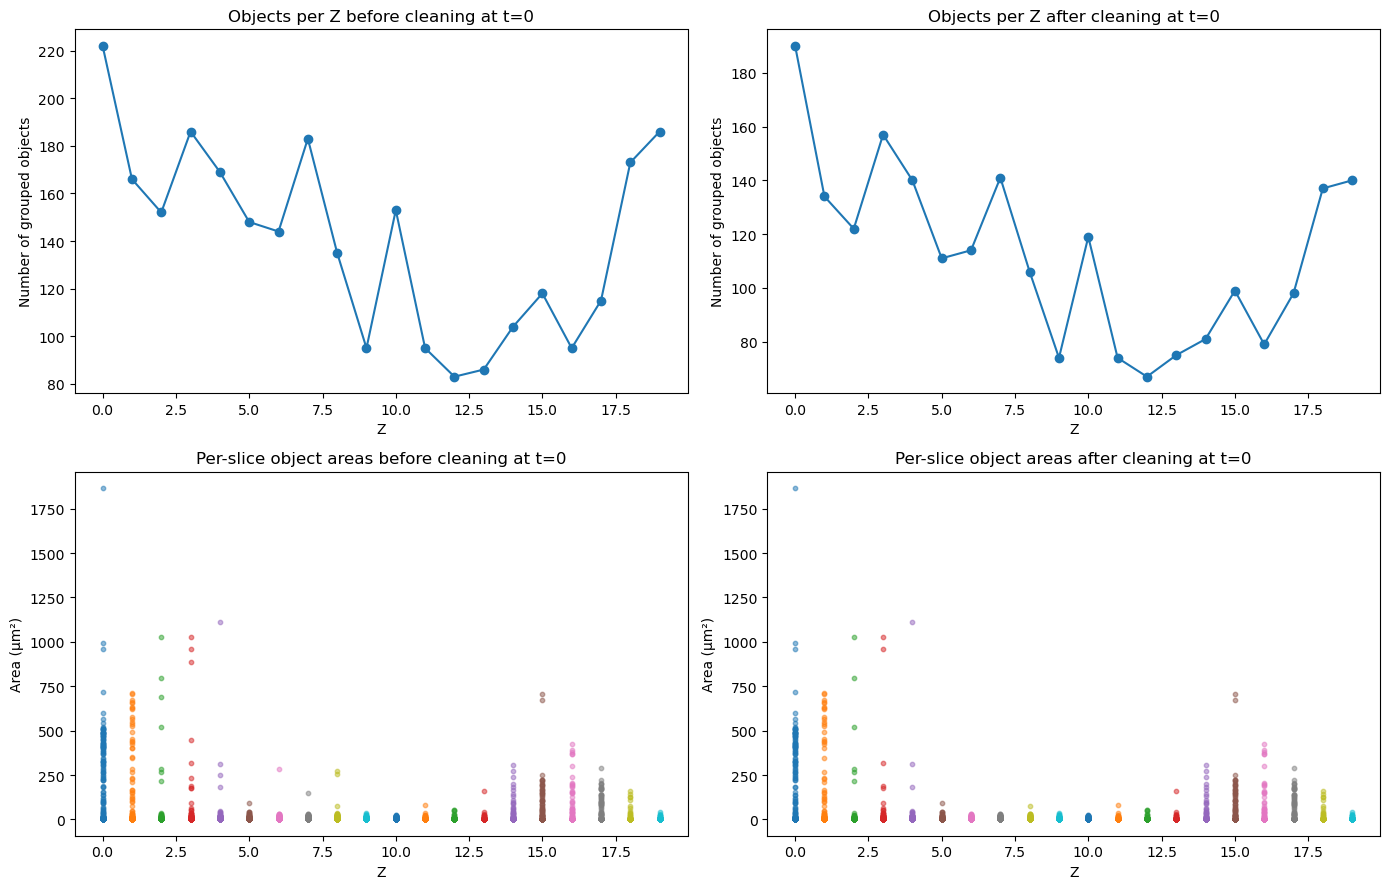

t=0
Raw rows: 2808
Cleaned rows: 2258
Removed rows: 550


In [22]:
plot_grouped_object_cleaning_diagnostics(
    raw_df=grouped_z_df,
    cleaned_df=grouped_z_clean_df,
    t_value=0,
    pixel_size_um=0.162,
)

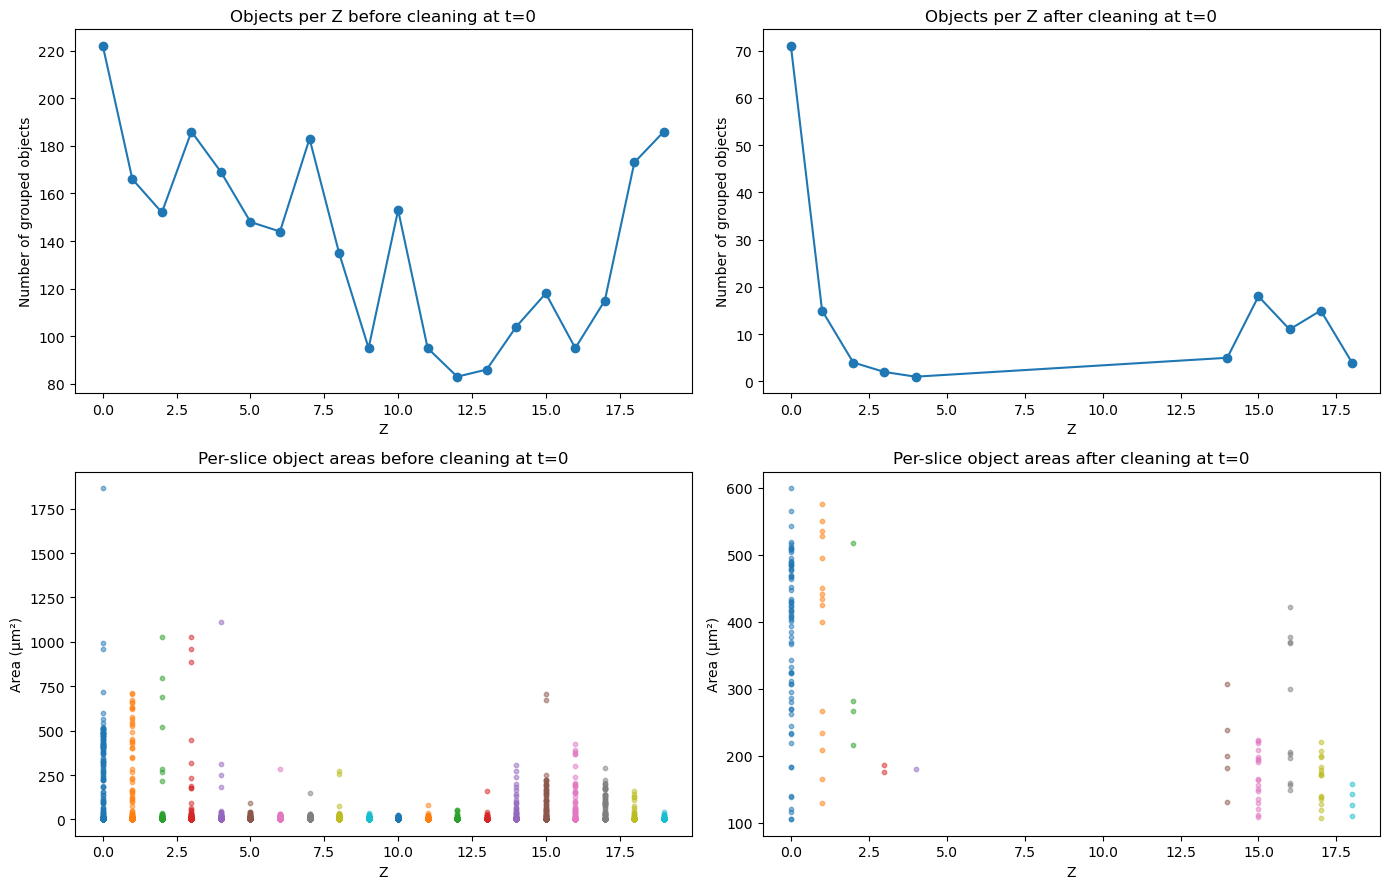

t=0
Raw rows: 2808
Cleaned rows: 146
Removed rows: 2662


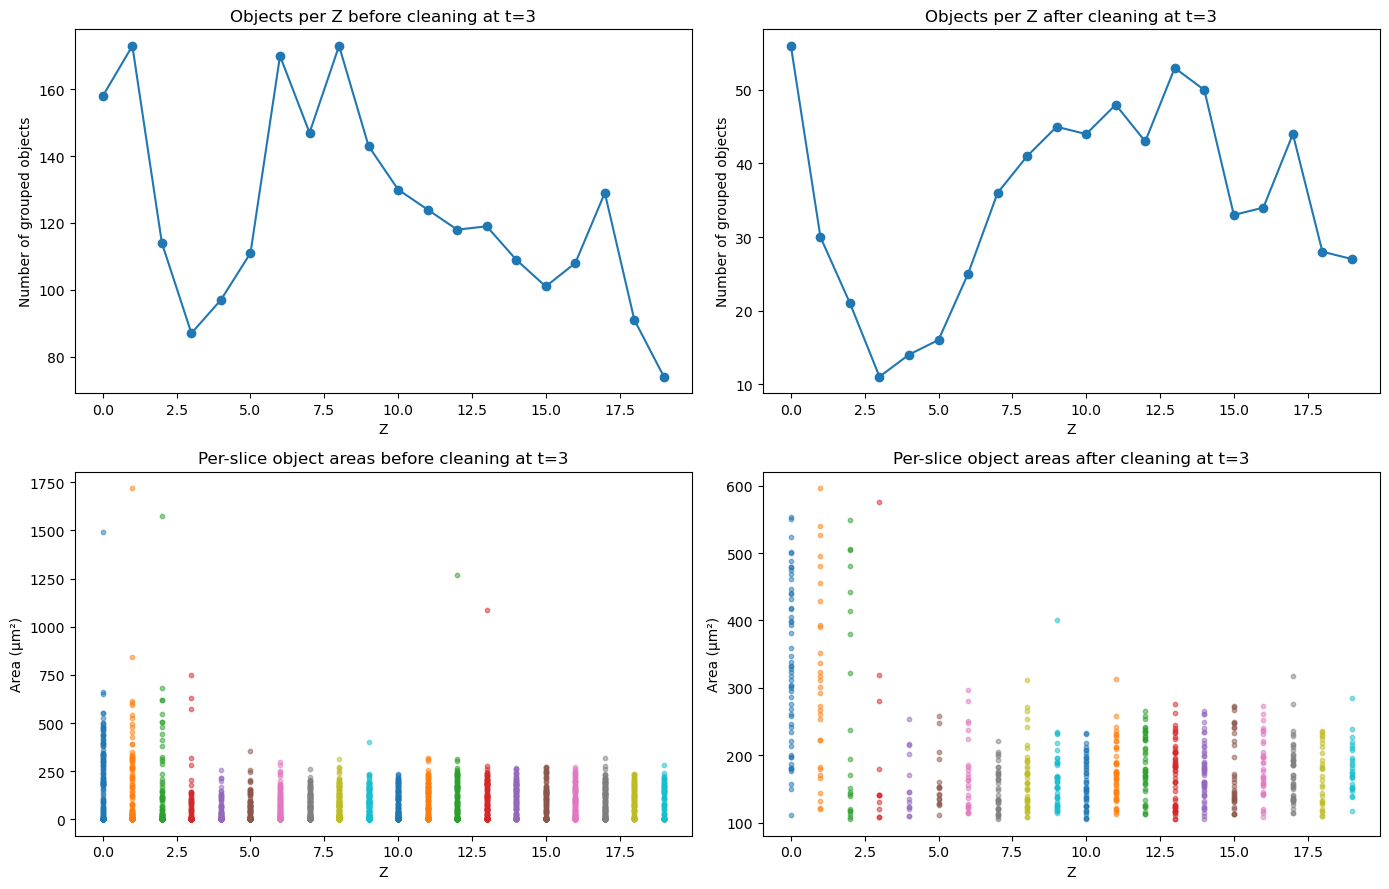

t=3
Raw rows: 2476
Cleaned rows: 699
Removed rows: 1777


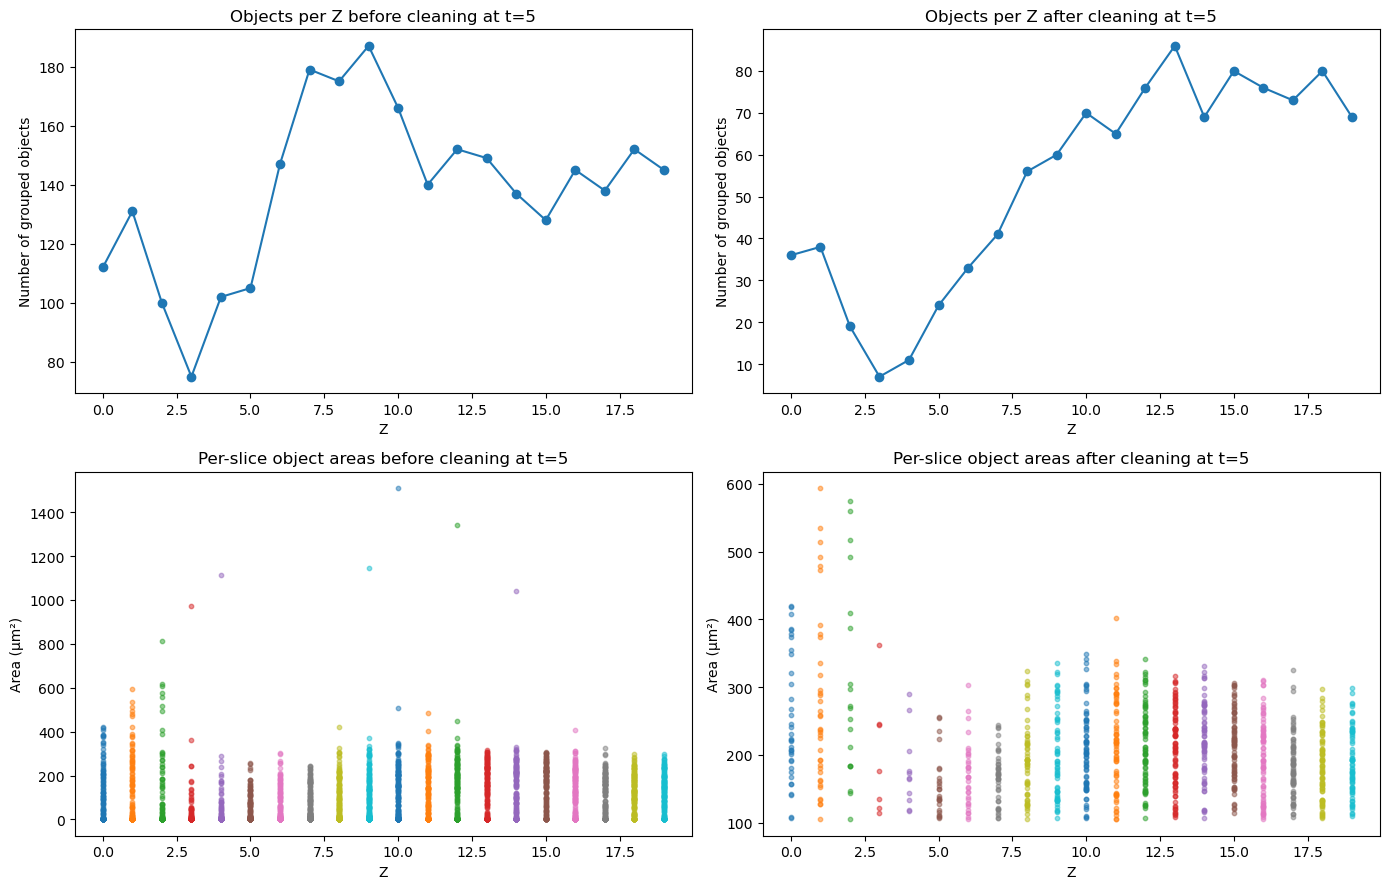

t=5
Raw rows: 2765
Cleaned rows: 1069
Removed rows: 1696


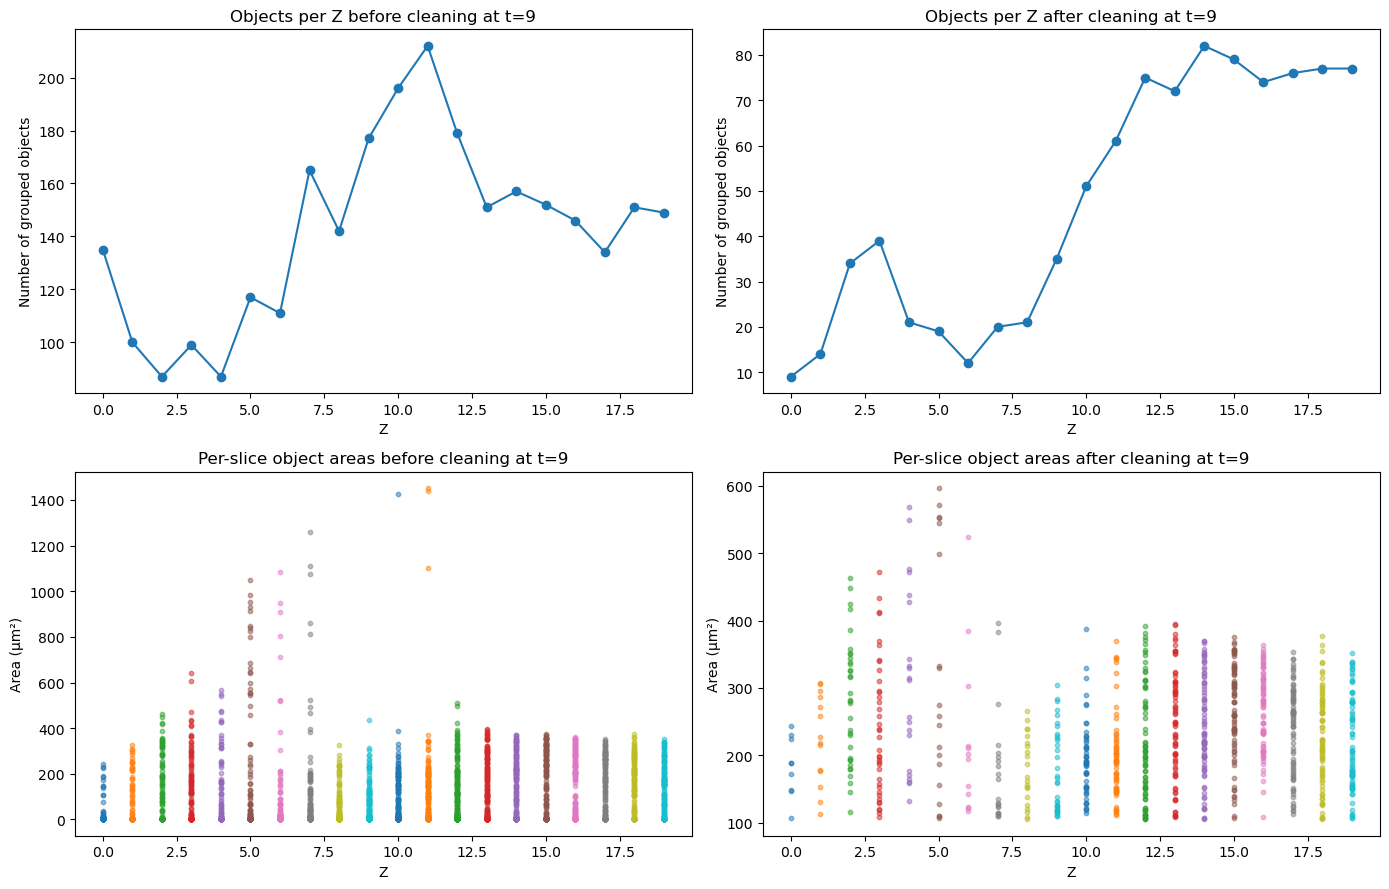

t=9
Raw rows: 2847
Cleaned rows: 948
Removed rows: 1899


In [30]:
for t_val in [0, 3, 5, 9]:
    plot_grouped_object_cleaning_diagnostics(
        raw_df=grouped_z_df,
        cleaned_df=grouped_z_clean_df,
        t_value=t_val,
        pixel_size_um=0.162,
    )

In [24]:
min_area_um2 = 120
pixel_size_um = 0.162

min_area_px = min_area_um2 / (pixel_size_um ** 2)

In [25]:
min_fill_fraction = 0.7

In [27]:
max_area_um2 = 450

In [28]:
grouped_z_clean_df = clean_grouped_objects_before_best_z(
    grouped_z_df,
    min_area_px=4000,          # ← BIG change
    min_fill_fraction=0.7,     # ← tighter
    min_circularity=None,
    remove_edge_touching=True,
    edge_buffer_px=5,
)

Rows after cleaning: 7602


In [29]:
grouped_z_clean_df["area_um2"] = grouped_z_clean_df["area_px"] * (0.162 ** 2)

grouped_z_clean_df = grouped_z_clean_df[
    grouped_z_clean_df["area_um2"] <= 600
]

In [31]:
print(grouped_z_clean_df["area_um2"].describe())

count    7421.000000
mean      214.584542
std        81.856110
min       104.976000
25%       152.162712
50%       200.792844
75%       258.687108
max       598.756860
Name: area_um2, dtype: float64


In [33]:
# Ensure area_um2 exists
if "area_um2" not in grouped_z_clean_df.columns:
    pixel_size_um = 0.162
    grouped_z_clean_df["area_um2"] = grouped_z_clean_df["area_px"] * (pixel_size_um ** 2)

# Compute stats
mean = grouped_z_clean_df["area_um2"].mean()
std = grouped_z_clean_df["area_um2"].std()

print(f"Mean: {mean:.2f}")
print(f"Std:  {std:.2f}")

# Define bounds
lower = 120
upper = mean + 2 * std

print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")

# Apply filter
filtered_df = grouped_z_clean_df[
    (grouped_z_clean_df["area_um2"] >= lower) &
    (grouped_z_clean_df["area_um2"] <= upper)
].copy()

print("Rows before:", len(grouped_z_clean_df))
print("Rows after:", len(filtered_df))

Mean: 214.58
Std:  81.86
Lower bound: 120.00
Upper bound: 378.30
Rows before: 7421
Rows after: 6543


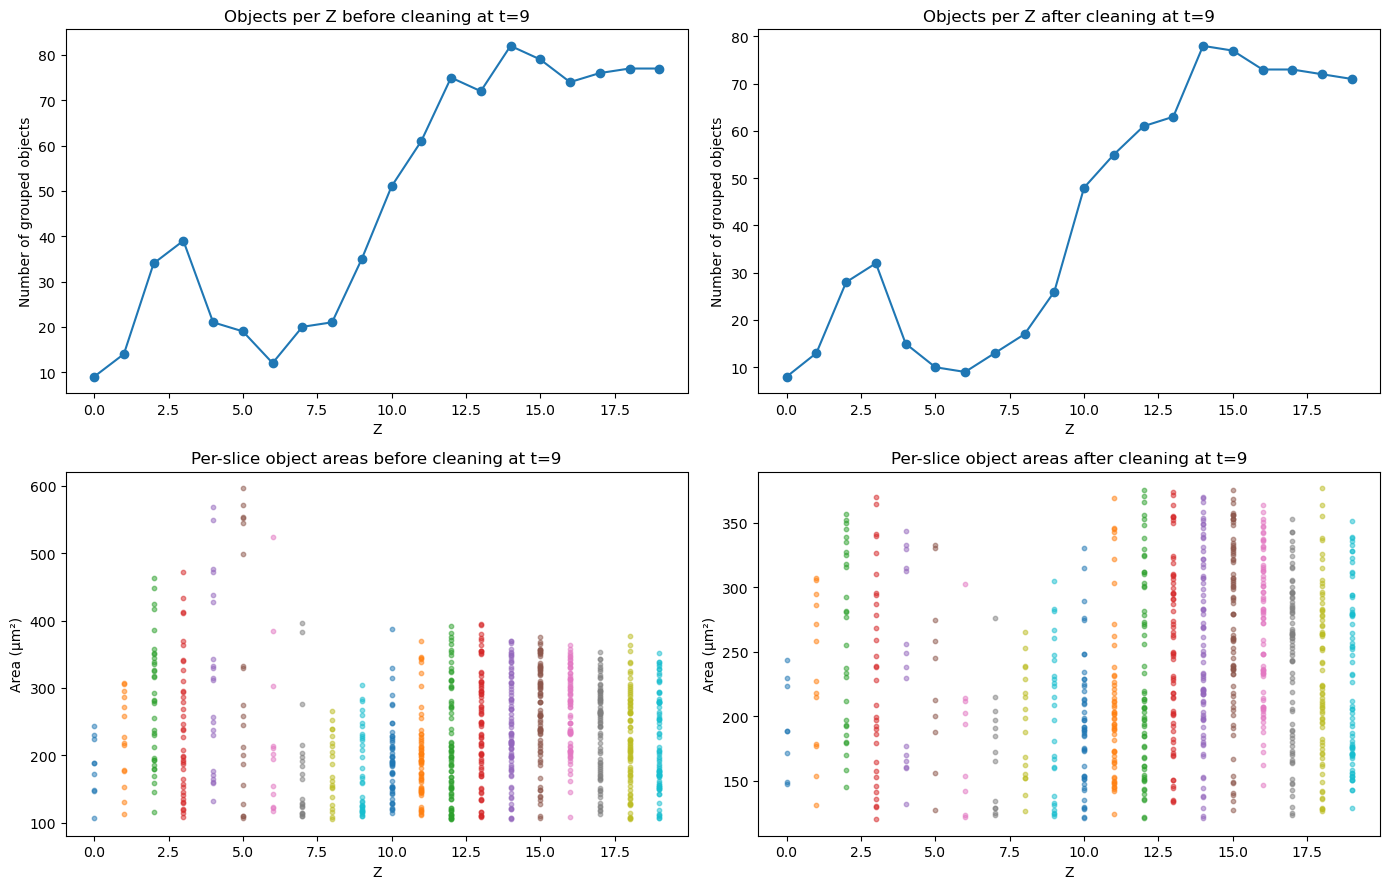

t=9
Raw rows: 948
Cleaned rows: 842
Removed rows: 106


In [35]:
plot_grouped_object_cleaning_diagnostics(
    raw_df=grouped_z_clean_df,
    cleaned_df=filtered_df,
    t_value=9,
    pixel_size_um=0.162,
)

In [36]:
import numpy as np
import pandas as pd


def group_objects_across_z(
    df: pd.DataFrame,
    max_dist_px: float = 20,
):
    """
    Assign nucleus_3d_id by linking objects across adjacent Z slices
    based on centroid proximity.
    """

    df = df.copy()
    df = df.sort_values(["t", "z"]).reset_index(drop=True)

    df["nucleus_3d_id"] = -1
    current_id = 0

    for t_val, t_df in df.groupby("t"):
        t_df = t_df.sort_values("z")

        prev_slice = None

        for z_val, z_df in t_df.groupby("z"):
            z_df = z_df.copy()

            if prev_slice is None:
                # initialize all objects
                for idx in z_df.index:
                    df.loc[idx, "nucleus_3d_id"] = current_id
                    current_id += 1
                prev_slice = z_df
                continue

            # match to previous slice
            for idx, row in z_df.iterrows():
                x, y = row["centroid_x_px"], row["centroid_y_px"]

                dists = np.sqrt(
                    (prev_slice["centroid_x_px"] - x) ** 2 +
                    (prev_slice["centroid_y_px"] - y) ** 2
                )

                if len(dists) > 0 and dists.min() < max_dist_px:
                    match_idx = prev_slice.index[dists.argmin()]
                    df.loc[idx, "nucleus_3d_id"] = df.loc[match_idx, "nucleus_3d_id"]
                else:
                    df.loc[idx, "nucleus_3d_id"] = current_id
                    current_id += 1

            prev_slice = z_df

    return df

In [37]:
grouped_df = group_objects_across_z(filtered_df)

In [38]:
valid_nuclei = (
    grouped_df.groupby("nucleus_3d_id")
    .filter(lambda g: len(g) >= 3)  # must exist in ≥3 Z slices
)

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def group_objects_across_z(
    df: pd.DataFrame,
    max_dist_px: float = 20,
):
    df = df.copy()
    df = df.sort_values(["t", "z"]).reset_index(drop=True)

    df["nucleus_3d_id"] = -1
    current_id = 0

    for t_val, t_df in df.groupby("t"):
        t_df = t_df.sort_values("z")
        prev_slice = None

        for z_val, z_df in t_df.groupby("z"):
            z_df = z_df.copy()

            if prev_slice is None:
                for idx in z_df.index:
                    df.loc[idx, "nucleus_3d_id"] = current_id
                    current_id += 1
                prev_slice = z_df
                continue

            for idx, row in z_df.iterrows():
                x, y = row["centroid_x_px"], row["centroid_y_px"]

                dists = np.sqrt(
                    (prev_slice["centroid_x_px"] - x) ** 2 +
                    (prev_slice["centroid_y_px"] - y) ** 2
                )

                if len(dists) > 0 and dists.min() < max_dist_px:
                    match_idx = prev_slice.index[dists.argmin()]
                    df.loc[idx, "nucleus_3d_id"] = df.loc[match_idx, "nucleus_3d_id"]
                else:
                    df.loc[idx, "nucleus_3d_id"] = current_id
                    current_id += 1

            prev_slice = z_df

    return df

In [40]:
def keep_valid_nuclei(
    df: pd.DataFrame,
    min_z_slices: int = 3,
) -> pd.DataFrame:
    if df is None or df.empty:
        print("No data to validate.")
        return df.copy()

    if "nucleus_3d_id" not in df.columns:
        raise ValueError("Missing required column 'nucleus_3d_id'")

    valid_ids = (
        df.groupby("nucleus_3d_id")["z"]
        .nunique()
        .loc[lambda s: s >= min_z_slices]
        .index
    )

    out = df[df["nucleus_3d_id"].isin(valid_ids)].copy()

    print("Total grouped rows:", len(df))
    print("Valid grouped rows:", len(out))
    print("Valid nuclei count:", out["nucleus_3d_id"].nunique())

    return out

In [41]:
def plot_valid_nuclei_diagnostics(
    df: pd.DataFrame,
    t_value: int,
    pixel_size_um: float,
    area_px_col: str = "area_px",
    z_col: str = "z",
):
    if df is None or df.empty:
        print("No valid nuclei to plot.")
        return

    plot_df = df[df["t"] == t_value].copy()
    if plot_df.empty:
        print(f"No valid nuclei found for t={t_value}")
        return

    if "area_um2" not in plot_df.columns:
        plot_df["area_um2"] = plot_df[area_px_col] * (pixel_size_um ** 2)

    counts = plot_df.groupby(z_col).size().reset_index(name="n_objects")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(counts[z_col], counts["n_objects"], marker="o")
    axes[0].set_title(f"Valid nuclei per Z at t={t_value}")
    axes[0].set_xlabel("Z")
    axes[0].set_ylabel("Number of valid nuclei")

    for z_val, g in plot_df.groupby(z_col):
        axes[1].scatter([z_val] * len(g), g["area_um2"], s=12, alpha=0.6)
    axes[1].set_title(f"Valid nucleus areas per Z at t={t_value}")
    axes[1].set_xlabel("Z")
    axes[1].set_ylabel("Area (µm²)")

    plt.tight_layout()
    plt.show()

In [42]:
grouped_valid_input_df = group_objects_across_z(filtered_df, max_dist_px=20)

valid_nuclei_df = keep_valid_nuclei(
    grouped_valid_input_df,
    min_z_slices=3,
)

Total grouped rows: 6543
Valid grouped rows: 3540
Valid nuclei count: 773


No valid nuclei found for t=0


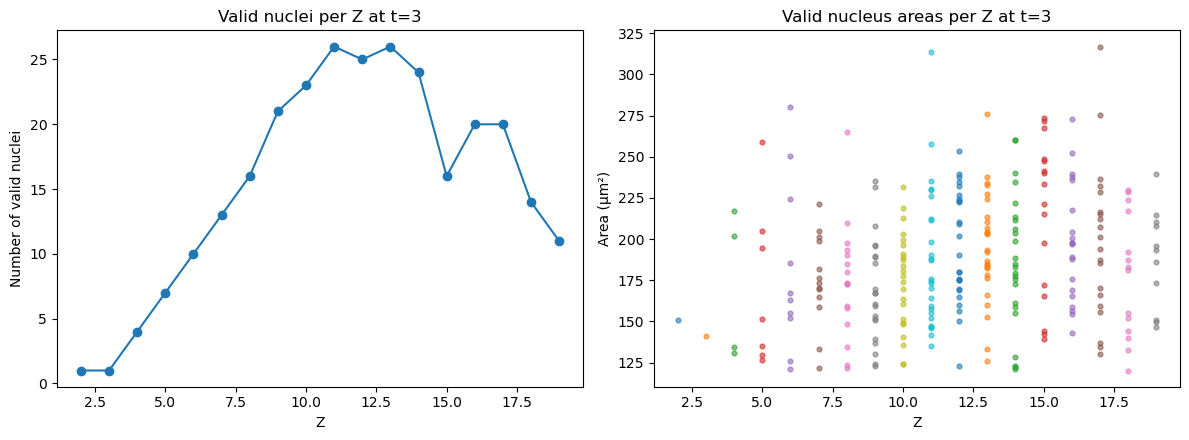

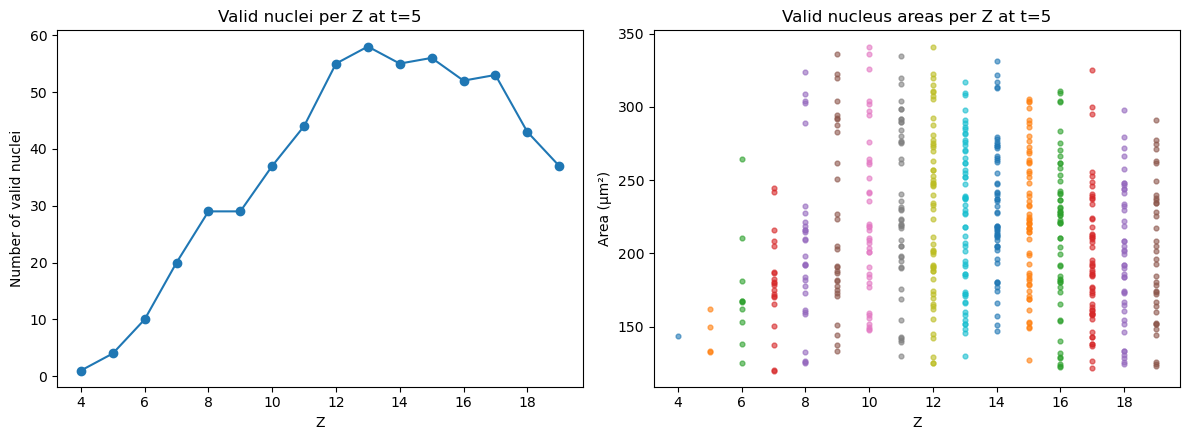

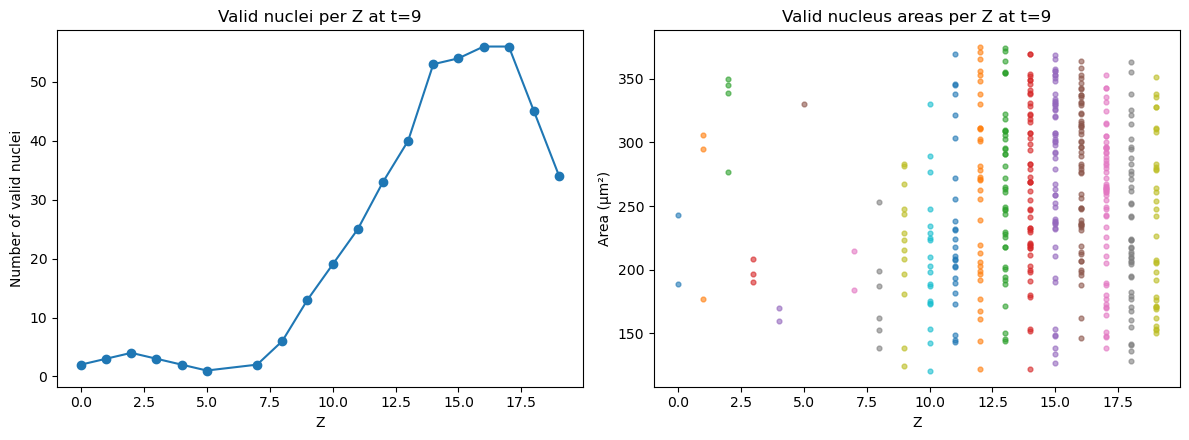

In [43]:
for t_val in [0, 3, 5, 9]:
    plot_valid_nuclei_diagnostics(
        valid_nuclei_df,
        t_value=t_val,
        pixel_size_um=0.162,
    )

In [47]:
best_z_valid_df = select_best_z_by_composite_score(
    valid_nuclei_df,
    group_col="nucleus_3d_id",
    z_col="z",
    area_col="area_px",
    circularity_col="circularity",
    fill_fraction_col="fill_fraction",
    edge_col="is_edge_touching",
    min_area_px=20,
)

In [63]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_selected_best_z_results(
    df: pd.DataFrame,
    pixel_size_um: float,
    n_fov: int = 6,
    serpentine: bool = True,
    area_px_col: str = "area_px",
    area_um2_col: str = "area_um2",
    title: str = "Best-Z max cross-sectional area vs time",
):
    if df is None or df.empty:
        print("No data to plot.")
        return df

    out = df.copy()

    # --- Ensure area_um2 exists ---
    if area_um2_col not in out.columns:
        if area_px_col not in out.columns:
            raise ValueError(f"Missing both '{area_um2_col}' and '{area_px_col}'")
        out[area_um2_col] = out[area_px_col] * (pixel_size_um ** 2)

    # --- Check required columns ---
    if "t" not in out.columns:
        raise ValueError("Missing required column 't'")
    if "centroid_x_px" not in out.columns:
        raise ValueError("Missing required column 'centroid_x_px'")

    # --- Reconstruct serpentine time ---
    max_x = out["centroid_x_px"].max()
    fov_width = max_x / n_fov

    out["fov_id"] = (out["centroid_x_px"] // fov_width).astype(int)
    out["fov_id"] = out["fov_id"].clip(0, n_fov - 1)

    if serpentine:
        reverse_mask = out["t"] % 2 == 1
        out.loc[reverse_mask, "fov_id"] = (n_fov - 1) - out.loc[reverse_mask, "fov_id"]

    out["true_time_min"] = out["t"] * n_fov + out["fov_id"]

    # --- Plot ---
    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        out["true_time_min"],
        out[area_um2_col],
        s=20,
        alpha=0.6,
    )

    plt.xlabel("Time (min)")
    plt.ylabel("Max cross-sectional area (µm²)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return out

In [64]:
best_z_valid_df = best_z_valid_df.copy()

if "area_um2" not in best_z_valid_df.columns:
    best_z_valid_df["area_um2"] = best_z_valid_df["area_px"] * (0.162 ** 2)

best_z_valid_df = best_z_valid_df[
    best_z_valid_df["area_um2"] >= 150
].copy()

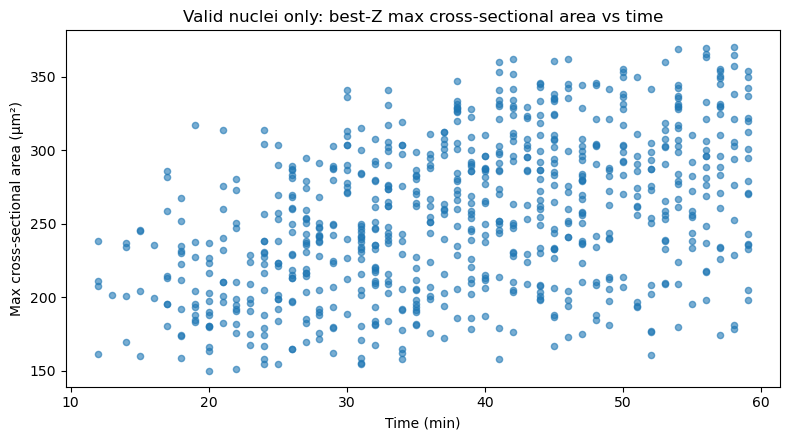

In [65]:
best_z_valid_df = plot_selected_best_z_results(
    best_z_valid_df,
    pixel_size_um=0.162,
    n_fov=6,
    serpentine=True,
    title="Valid nuclei only: best-Z max cross-sectional area vs time",
)

In [66]:
import pandas as pd
import matplotlib.pyplot as plt


def apply_time_aware_final_area_filter(
    df: pd.DataFrame,
    pixel_size_um: float = 0.162,
    area_px_col: str = "area_px",
    area_um2_col: str = "area_um2",
    time_col: str = "true_time_min",
    early_time_max: float = 20,
    mid_time_max: float = 40,
    early_min_area_um2: float = 50,
    mid_min_area_um2: float = 160,
    late_min_area_um2: float = 250,
):
    if df is None or df.empty:
        print("No data to filter.")
        return df.copy()

    out = df.copy()

    if area_um2_col not in out.columns:
        if area_px_col not in out.columns:
            raise ValueError(f"Missing both '{area_um2_col}' and '{area_px_col}'")
        out[area_um2_col] = out[area_px_col] * (pixel_size_um ** 2)

    if time_col not in out.columns:
        raise ValueError(f"Missing required column '{time_col}'")

    keep_early = (
        (out[time_col] < early_time_max) &
        (out[area_um2_col] >= early_min_area_um2)
    )

    keep_mid = (
        (out[time_col] >= early_time_max) &
        (out[time_col] < mid_time_max) &
        (out[area_um2_col] >= mid_min_area_um2)
    )

    keep_late = (
        (out[time_col] >= mid_time_max) &
        (out[area_um2_col] >= late_min_area_um2)
    )

    keep = keep_early | keep_mid | keep_late
    filtered = out[keep].copy()

    print("Rows before final time-aware filter:", len(out))
    print("Rows after final time-aware filter:", len(filtered))

    return filtered

In [85]:
best_z_valid_timeaware_df = apply_time_aware_final_area_filter(
    best_z_valid_df,
    pixel_size_um=0.162,
    time_col="true_time_min",
    early_time_max=20,
    mid_time_max=40,
    early_min_area_um2=0,
    mid_min_area_um2=160,
    late_min_area_um2=180,
)

Rows before final time-aware filter: 758
Rows after final time-aware filter: 737


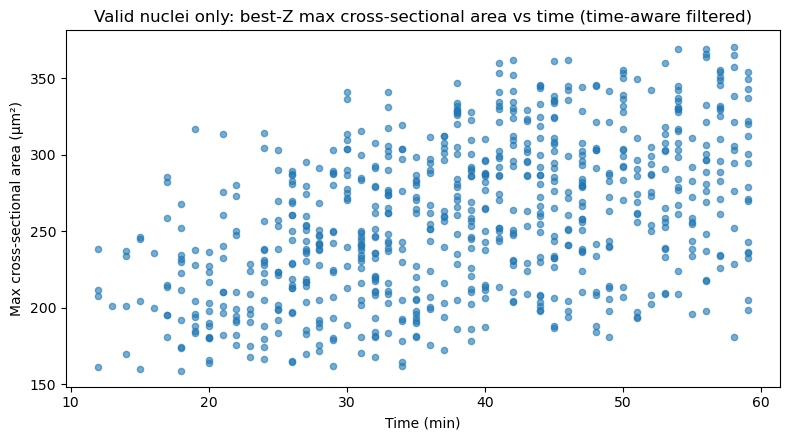

In [68]:
best_z_valid_timeaware_df = plot_selected_best_z_results(
    best_z_valid_timeaware_df,
    pixel_size_um=0.162,
    n_fov=6,
    serpentine=True,
    title="Valid nuclei only: best-Z max cross-sectional area vs time (time-aware filtered)",
)

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_nc_ratio_vs_time(
    df: pd.DataFrame,
    pixel_size_um: float = 0.162,
    n_fov: int = 6,
    serpentine: bool = True,
    nucleus_mean_col: str = "nucleus_mean_intensity",
    cytoplasm_mean_col: str = "cytoplasm_mean_intensity",
    title: str = "N/C ratio vs time",
):
    if df is None or df.empty:
        print("No data to plot.")
        return df

    out = df.copy()

    # --- Check required columns ---
    required = ["t", "centroid_x_px", nucleus_mean_col, cytoplasm_mean_col]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # --- Reconstruct serpentine time ---
    max_x = out["centroid_x_px"].max()
    fov_width = max_x / n_fov

    out["fov_id"] = (out["centroid_x_px"] // fov_width).astype(int)
    out["fov_id"] = out["fov_id"].clip(0, n_fov - 1)

    if serpentine:
        reverse_mask = out["t"] % 2 == 1
        out.loc[reverse_mask, "fov_id"] = (n_fov - 1) - out.loc[reverse_mask, "fov_id"]

    out["true_time_min"] = out["t"] * n_fov + out["fov_id"]

    # --- Compute N/C ratio ---
    N = out[nucleus_mean_col]
    C = out[cytoplasm_mean_col]

    # Avoid division issues
    out["nc_ratio"] = N / (N + C.replace(0, np.nan))

    # --- Plot ---
    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        out["true_time_min"],
        out["nc_ratio"],
        s=15,
        alpha=0.5,
    )

    # --- Smooth trend (moving average) ---
    out_sorted = out.sort_values("true_time_min")
    window = max(10, len(out_sorted) // 50)

    smoothed = (
        out_sorted[["true_time_min", "nc_ratio"]]
        .rolling(window=window, min_periods=1)
        .mean()
    )

    plt.plot(
        smoothed["true_time_min"],
        smoothed["nc_ratio"],
        linewidth=2,
    )

    plt.xlabel("Time (min)")
    plt.ylabel("N / (N + C)")
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

    return out

In [74]:
tables_to_check = {
    "best_z_valid_timeaware_df": best_z_valid_timeaware_df if "best_z_valid_timeaware_df" in globals() else None,
    "best_z_valid_df": best_z_valid_df if "best_z_valid_df" in globals() else None,
    "halo_df": halo_df if "halo_df" in globals() else None,
    "tracked_df": tracked_df if "tracked_df" in globals() else None,
}

for name, table in tables_to_check.items():
    print(f"\n{name}")
    if table is None:
        print("missing")
    else:
        print(table.columns.tolist())


best_z_valid_timeaware_df
['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'bbox_area_px', 'fill_fraction', 'is_edge_touching', 'area_um2', 'circularity', 'area_norm', 'circ_norm', 'fill_norm', 'edge_penalty_val', 'z_score', 'fov_id', 'true_time_min']

best_z_valid_df
['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'bbox_area_px', 'fill_fraction', 'is_edge_touching', 'area_um2', 'circularity', 'area_norm', 'circ_norm', 'fill_norm', 'edge_penalty_val', 'z_score', 'fov_id', 'true_time_min']

halo_df
['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'valid_single_nucleus', 'tile_row', 'tile_col', 'tile_index', 'tile_offset_min', 'true_time_min', 'global_index', 'track_id', 'track_link_distance_px', 'tr

In [79]:
valid_ids = best_z_valid_timeaware_df["nucleus_3d_id"].unique()

halo_filtered_df = halo_df[
    halo_df["nucleus_3d_id"].isin(valid_ids)
].copy()

print("Halo rows before:", len(halo_df))
print("Halo rows after:", len(halo_filtered_df))

Halo rows before: 19443
Halo rows after: 737


In [82]:
# Keep only the selected best-Z nucleus objects using shared object keys
best_z_keys = best_z_valid_timeaware_df[
    ["t", "z", "label"]
].drop_duplicates().copy()

halo_bestz_df = halo_df.merge(
    best_z_keys,
    on=["t", "z", "label"],
    how="inner"
).copy()

print("Halo rows before:", len(halo_df))
print("Rows after best-Z filtering:", len(halo_bestz_df))

Halo rows before: 19443
Rows after best-Z filtering: 468


In [83]:
import matplotlib.pyplot as plt


def plot_nc_ratio_from_halo(
    df,
    title="N/C ratio vs time (final filtered nuclei)"
):
    if df is None or df.empty:
        print("No data to plot.")
        return

    required = ["true_time_min", "nc_ratio_fraction"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    plot_df = df.dropna(subset=["true_time_min", "nc_ratio_fraction"]).copy()
    plot_df = plot_df.sort_values("true_time_min")

    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        plot_df["true_time_min"],
        plot_df["nc_ratio_fraction"],
        s=15,
        alpha=0.5,
    )

    smooth = plot_df["nc_ratio_fraction"].rolling(
        window=max(10, len(plot_df) // 50),
        min_periods=1
    ).mean()

    plt.plot(plot_df["true_time_min"], smooth, linewidth=2)

    plt.xlabel("Time (min)")
    plt.ylabel("N / (N + C)")
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

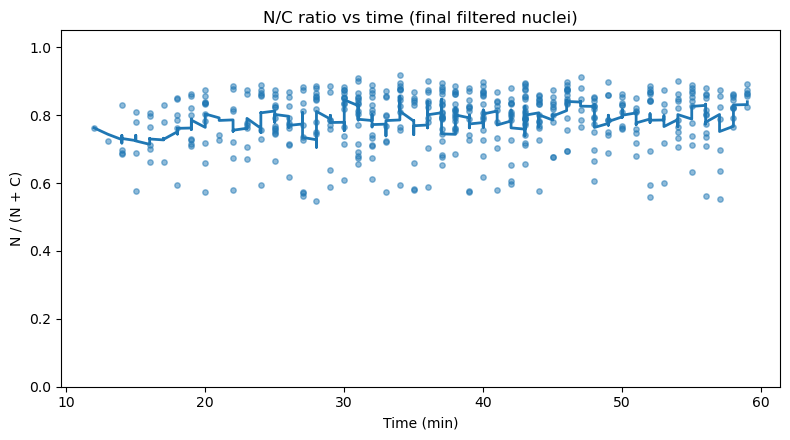

In [84]:
plot_nc_ratio_from_halo(halo_bestz_df)

In [76]:
# Build lookup for best Z per nucleus/time
best_z_lookup = best_z_valid_timeaware_df[
    ["nucleus_3d_id", "t", "z"]
].copy()

best_z_lookup = best_z_lookup.rename(columns={"z": "best_z"})

# Merge
halo_bestz_df = halo_filtered_df.merge(
    best_z_lookup,
    on=["nucleus_3d_id", "t"],
    how="inner"
)

# Keep only matching Z
halo_bestz_df = halo_bestz_df[
    halo_bestz_df["z"] == halo_bestz_df["best_z"]
].copy()

print("Rows after best-Z filtering:", len(halo_bestz_df))

Rows after best-Z filtering: 0


In [80]:
import matplotlib.pyplot as plt


def plot_nc_ratio_from_halo(
    df,
    title="N/C ratio vs time (final filtered nuclei)"
):
    if df is None or df.empty:
        print("No data to plot.")
        return

    required = ["true_time_min", "nc_ratio_fraction"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    plot_df = df.dropna(subset=["nc_ratio_fraction"]).copy()

    plt.figure(figsize=(8, 4.5))

    plt.scatter(
        plot_df["true_time_min"],
        plot_df["nc_ratio_fraction"],
        s=15,
        alpha=0.5,
    )

    # Smooth curve
    plot_df = plot_df.sort_values("true_time_min")
    smooth = plot_df["nc_ratio_fraction"].rolling(
        window=max(10, len(plot_df)//50),
        min_periods=1
    ).mean()

    plt.plot(plot_df["true_time_min"], smooth, linewidth=2)

    plt.xlabel("Time (min)")
    plt.ylabel("N / (N + C)")
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

In [81]:
plot_nc_ratio_from_halo(halo_bestz_df)

No data to plot.


## 12. Slim napari viewer

In [ ]:

def open_nuclear_only_napari(
    seg_class,
    nucleus_instance,
    t_idx: int = 0,
    show_all_z: bool = True,
):
    import napari

    nuclear_labels = None
    roi_mask = None

    if seg_class is not None:
        arr = seg_class
        if arr.ndim == 5:      # (T, Z, C, Y, X)
            arr = arr[t_idx]
        elif arr.ndim == 4 and nucleus_instance is not None and getattr(nucleus_instance, "ndim", None) == 4:
            arr = arr[t_idx]

        if arr.ndim == 4 and arr.shape[1] <= 10:
            nuclear_labels = np.argmax(arr, axis=1).astype(np.uint8)
        elif arr.ndim == 3:
            nuclear_labels = arr.astype(np.uint8)
        else:
            raise ValueError(f"Unsupported seg_class shape after slicing: {arr.shape}")

    if nucleus_instance is not None:
        arr = nucleus_instance
        if arr.ndim == 4:
            arr = arr[t_idx]
        elif arr.ndim != 3:
            raise ValueError(f"Unsupported nucleus_instance shape: {arr.shape}")
        roi_mask = arr

    if not show_all_z:
        if nuclear_labels is not None and nuclear_labels.ndim == 3:
            nuclear_labels = nuclear_labels[nuclear_labels.shape[0] // 2]
        if roi_mask is not None and roi_mask.ndim == 3:
            roi_mask = roi_mask[roi_mask.shape[0] // 2]

    viewer = napari.Viewer()
    if nuclear_labels is not None:
        viewer.add_labels(nuclear_labels, name="nuclear_class_labels")
    if roi_mask is not None:
        viewer.add_labels(roi_mask, name="nuclear_roi_mask")
    return viewer


In [ ]:

if AUTO_OPEN_NAPARI:
    viewer = open_nuclear_only_napari(
        seg_class=mask_arrays["segmentation_class"],
        nucleus_instance=mask_arrays["nucleus_instance"],
        t_idx=NAPARI_T_IDX,
        show_all_z=NAPARI_SHOW_ALL_Z,
    )


## 13. Useful quick checks

In [ ]:

print("best_z_df columns:")
print([] if best_z_df is None else list(best_z_df.columns))

if best_z_df is not None and "true_time_min" in best_z_df.columns:
    print("\nUnique true_time_min values:")
    print(sorted(best_z_df["true_time_min"].dropna().unique())[:100])
    print("Count:", best_z_df["true_time_min"].nunique())

if best_z_df is not None and "t" in best_z_df.columns:
    print("\nUnique t values:")
    print(sorted(best_z_df["t"].dropna().unique())[:100])
    print("Count:", best_z_df["t"].nunique())
